In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipynbname
import os
import json
import unicodedata, re

In [2]:
notebook_path = ipynbname.path()
notebook_dir = os.path.dirname(notebook_path)

# 1. Import data and define variables

Data collection was done in November 2025; it included data from different sources:

- Register of Buildings and Dwellings (https://www.housing-stat.ch/it/madd/public.html#scaricare_i_dati) --> has data of building properties and heating technology
- Electricity production plants (https://www.geocat.ch/geonetwork/srv/ita/catalog.search#/metadata/e5a00bdb-5022-4856-ad4a-d1afe7bf38b0) --> has the data related to all production plants actually installed in Switzerland
- Suitability of roofs for the use of solar energy (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/b614de5c-2f12-4355-b2c9-7aef2c363ad6)
- Cadastral data (https://www.geocat.ch/geonetwork/srv/eng/catalog.search#/metadata/a3c0f7fb-1be0-4385-9c54-33b65ae3e1ae) --> has the shapefiles of each infrastructure in Switzerland. These data is not available for all the Cantons.

The output of the first data collection is one unique dataframe that contains for each residential building in Switzerland the data related to its properties, heating technology, PV plant presence and shape (for the Cantons with open cadastral data available) - here named 'gdf_input'.

In [3]:
gdf_file = '/data/gdf_input.gpkg'

gdf_raw = gpd.read_file(notebook_dir + gdf_file)
gdf = gdf_raw.to_crs(epsg=2056)

In [4]:
gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']] = gdf[['GKLAS', 'GBAUP', 'GWAERZH1', 'GWAERZH2', 'GWAERZW1', 'GENH1', 'GENH2', 'GENW1']].fillna(0)

In [5]:
gdf["Type"] = gdf["GKLAS"].map({1110: "SFH", 1121: "DFH", 1122: "MFH"}).fillna("No Info")
gdf["Construction Period"] = pd.cut(gdf["GBAUP"], bins=[-float("inf"), 8011, 8012, 8013, 8014, 8015, 8017, 8019, 8021, float("inf")],
                                    labels=["< 1920", "1921-1945", "1946-1960", "1961-1970", "1971-1980", "1981-1990", "1991-2000", "2001-2010", "> 2010"])
gdf["Gen_SH"] = pd.cut(gdf["GWAERZH1"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_SH2"] = pd.cut(gdf["GWAERZH2"], bins=[-float("inf"), 1, 7400, 7411, 7421, 7435, 7436, 7441, 7452, 7461, float("inf")],
                       labels=["", "No_Heating", "HP", "ST", "Boiler", "Heater", "Cogeneration", "EH", "DH", "Indeterminate"])
gdf["Gen_DHW"] = pd.cut(gdf["GWAERZW1"], bins=[-float("inf"), 1, 7600, 7610, 7620, 7634, 7640, 7651, float("inf")],
                        labels=["", "No_Heating", "HP", "ST", "Boiler", "Cogeneration", "EH", "Indeterminate"])
gdf["Energy_SH"] = pd.cut(gdf["GENH1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_SH2"] = pd.cut(gdf["GENH2"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                          labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])
gdf["Energy_DHW"] = pd.cut(gdf["GENW1"], bins=[-float("inf"), 1, 7500, 7501, 7512, 7513, 7520, 7530, 7543, 7560, 7570, 7582, float("inf")],
                           labels=["", "No_Heating", "Aria", "Geothermic", "Water", "Gas_Boiler", "Oil_Boiler", "Wood_Boiler", "EH", "ST", "DH", "Indeterminate"])

In [6]:
gdf["Tech_SH"] = np.where(gdf["Gen_SH"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH"], gdf["Energy_SH"])
gdf["Tech_SH2"] = np.where(gdf["Gen_SH2"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_SH2"], gdf["Energy_SH2"])
gdf["Tech_DHW"] = np.where(gdf["Gen_DHW"].isin(["HP", "Cogeneration", "ST", "EH", "No_Heating", "DH"]), gdf["Gen_DHW"], gdf["Energy_DHW"])

gdf["Heating_SH"] = np.where(
    gdf["Tech_SH"] == gdf["Tech_SH2"], gdf["Tech_SH"],
    gdf["Tech_SH"] + "_&_" + gdf["Tech_SH2"])

gdf["Heating_Tech"] = (
    np.where(gdf["Heating_SH"].isin(["HP_&_Oil_Boiler", "HP_&_Gas_Boiler", "Gas_Boiler_&_ST", "Oil_Boiler_&_ST", "HP_&_ST", "Wood_Boiler_&_ST"]), gdf["Heating_SH"],
    np.where(gdf["Tech_SH"].isin(["Indeterminate", "No_Heating", ""]), gdf["Tech_DHW"],
    np.where(gdf["Tech_SH"] == gdf["Tech_DHW"], gdf["Tech_SH"], gdf["Tech_SH"] + "_&_" + gdf["Tech_DHW"]))))

In [7]:
tech_simplification_map = {
    'Oil': ["Oil_Boiler", "Oil_Boiler_&_", "Oil_Boiler_&_Gas_Boiler", "Oil_Boiler_&_Wood_Boiler", "Oil_Boiler_&_DH", "Oil_Boiler_&_EH", "Oil_Boiler_&_Geothermic", "Indeterminate_&_Oil_Boiler", "Oil_Boiler_&_Indeterminate", "Oil_Boiler_&_No_Heating", 'Oil_Boiler_&_Cogeneration', "Oil_Boiler_&_HP", "Oil_Boiler_&_Aria"],

    'Gas': ["Gas_Boiler", "Gas_Boiler_&_", "Gas_Boiler_&_Oil_Boiler", "Gas_Boiler_&_Wood_Boiler", "Gas_Boiler_&_DH", "Gas_Boiler_&_EH", "Indeterminate_&_Gas_Boiler", "Gas_Boiler_&_Indeterminate", "Gas_Boiler_&_No_Heating", "Gas_Boiler_&_HP", "Gas_Boiler_&_Aria"],

    'Wood': ["Wood_Boiler", "Wood_Boiler_&_", "Wood_Boiler_&_Gas_Boiler", "Wood_Boiler_&_HP", "Wood_Boiler_&_Oil_Boiler", "Wood_Boiler_&_DH", "Wood_Boiler_&_EH", "Wood_Boiler_&_Aria", "Wood_Boiler_&_Geothermic", "Wood_Boiler_&_Water", "Wood_Boiler_&_Cogeneration", "Indeterminate_&_Wood_Boiler", "Wood_Boiler_&_No_Heating", "Wood_Boiler_&_Indeterminate"],

    'HeatPump': ["HP_&_Wood_Boiler", "HP_&_", "HP_&_DH", "HP_&_EH", "HP_&_Cogeneration", "Aria_&_Wood_Boiler", "HP_&_Water", "Aria", "Aria_&_HP", "HP_&_Geothermic", "HP_&_Aria", "Indeterminate_&_HP", "HP_&_Indeterminate", "HP_&_No_Heating", "Water", "Aria_&_Indeterminate", 'HP', "HP_&_Oil_Boiler", "Aria_&_Oil_Boiler", "HP_&_Gas_Boiler", "Aria_&_Gas_Boiler"],

    'ElectricHeater': ["EH_&_HP", "EH_&_", "EH_&_ST", "EH_&_Oil_Boiler", "EH_&_Gas_Boiler", "EH_&_Wood_Boiler", "EH_&_DH", "DH_&_Geothermic", "EH_&_Water", "EH_&_Cogeneration", "Water_&_EH", "Aria_&_EH", "Indeterminate_&_EH", "EH_&_Indeterminate", "EH_&_No_Heating", 'EH'],

    'DH': ["DH_&_Oil_Boiler", "DH_&_", "ST_&_", "DH_&_EH", "DH_&_Wood_Boiler", "DH_&_Gas_Boiler", "DH_&_HP", "DH_&_ST", "DH_&_Cogeneration", "Geothermic_&_ST", "Geothermic_&_Wood_Boiler", "Cogeneration_&_HP", "Geothermic_&_EH", "Cogeneration_&_EH", "Geothermic_&_HP", "Indeterminate_&_DH", "ST_&_EH", "ST_&_HP", "DH_&_Indeterminate", "ST_&_Wood_Boiler", "ST_&_Oil_Boiler", "ST_&_Indeterminate", "DH_&_No_Heating", "ST_&_Gas_Boiler", "Geothermic", "Cogeneration", "ST_&_DH", "Geothermic_&_Indeterminate", "ST_&_No_Heating", "Geothermic_&_Oil_Boiler", "Cogeneration_&_Indeterminate","Cogeneration_&_Wood_Boiler", "Geothermic_&_Gas_Boiler", "Cogeneration_&_Oil_Boiler", "ST", 'Geothermic_&_No_Heating', 'Water_&_DH', 'ST_&_Geothermic', 'DH'],

    'No info': ["Indeterminate_&_Geothermic", "Indeterminate_&_Water", "Indeterminate_&_Aria", "Indeterminate", ""],

    'No heating': ["No_Heating_&_Aria", "No_Heating_&_DH", "No_Heating_&_HP", "No_Heating_&_ST", "No_Heating_&_Oil_Boiler", "No_Heating_&_Wood_Boiler", "No_Heating_&_Gas_Boiler", "No_Heating_&_EH", "No_Heating"],

    'HPST': ["HP_&_ST", "Aria_&_ST"],

    'GasST': ["Gas_Boiler_&_ST"],

    'WoodST': ["Wood_Boiler_&_ST"],

    'OilST': ["Oil_Boiler_&_ST"]
}

In [8]:
def simplify_heating_tech(tech):
    for key, values in tech_simplification_map.items():
        if tech in values:
            return key
    return tech
 # Vale solo la prima tecnologia che viene trovata, se ho un oil boiler e una heat pump, mi salva solo oil boiler, è voluto?


''' reverse_map = {v: k for k, vals in tech_simplification_map.items() for v in vals}

def simplify_heating_tech(tech):
    return reverse_map.get(tech, tech)
# Mi sovrascrive solo l'ultima tecnologia che trova, se ho un oil boiler e una heat pump, mi salva solo heat pump 
# In teoria più computativamente efficiente'''

" reverse_map = {v: k for k, vals in tech_simplification_map.items() for v in vals}\n\ndef simplify_heating_tech(tech):\n    return reverse_map.get(tech, tech)\n# Mi sovrascrive solo l'ultima tecnologia che trova, se ho un oil boiler e una heat pump, mi salva solo heat pump \n# In teoria più computativamente efficiente"

In [9]:
gdf["Heating Technology"] = gdf["Heating_Tech"].apply(simplify_heating_tech)
gdf['PV'] = np.where(gdf['TotalPower'] > 0, 'PVyes', 'PVno')
gdf['PV power'] = np.where(gdf['TotalPower'] > 0, gdf['TotalPower'], 0)
gdf['PV power'] = gdf['PV power'].astype(float)

In [10]:
gdf["Initial operation Heating"] = np.where(gdf["Construction Period"] == "> 2010", gdf["GBAUJ"], pd.to_datetime(gdf["GWAERDATH1"], errors='coerce').dt.year)

gdf["Initial operation PV"] = np.where(gdf["BeginningOfOperation"] != 0, pd.to_datetime(gdf["BeginningOfOperation"], errors='coerce').dt.year, gdf["BeginningOfOperation"])
gdf['Initial operation PV'] = gdf['Initial operation PV'].fillna(0)
gdf['Initial operation PV'] = gdf['Initial operation PV'].astype(float)

gdf["Reference Area [m2]"] = np.where(gdf["GEBF"] > 0, gdf["GEBF"], 0)
gdf['Specific Roof Potential [kWh/m2y]'] = gdf['STROMERTRAG'] / gdf['FLAECHE']

C:\Users\andre\AppData\Local\Temp\ipykernel_42060\2626516526.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf['Initial operation PV'] = gdf['Initial operation PV'].fillna(0)


In [11]:
gdf = gdf.drop(columns=['EGID', 'OBJID', 'R1_OBJID', 'GKODE', 'GKODN', 'GSTAT', 'GKAT', 'GKLAS', 'GBAUP', 'GAREA', 'GASTW', 'GANZWHG', 'GEBF', 'GWAERZH1', 'GWAERZH2', 'GENH1', 'GENH2', 'GWAERDATH1', 'GWAERZW1', 'GENW1', 'GWAERSCEW1', 'BeginningOfOperation', 'TotalPower', 'Gen_SH', 'Gen_SH2', 'Gen_DHW', 'Energy_SH', 'Energy_SH2', 'Energy_DHW', 'Tech_SH', 'Tech_SH2', 'Tech_DHW', 'Heating_Tech', 'Heating_SH', 'R1_EGRIS_E', 'GWAERSCEH1', 'STROMERTRAG', 'STROMERTRAG_SOMMERHALBJAHR', 'STROMERTRAG_WINTERHALBJAHR', 'PV power', 'Initial operation Heating', 'Initial operation PV'])
gdf = gdf.rename(columns={'GDEKT': 'Canton',
                          'GGDENAME': 'Municipality',
                          'FLAECHE': 'Roof area [m2]',
                          'GBAUJ': 'Construction Year',
                          "Reference Area [m2]": "Area [m2]"})

# 2. Add adoption drivers

Add all the possible drivers to be used to describe PV and HP adoption. When the data is not available, the average over Switzerland is assumed.

In [12]:

gdf_2025_drivers = gdf.copy()

In [13]:
if gdf_2025_drivers.geom_type.isin(["Polygon", "MultiPolygon"]).any():
    gdf_2025_drivers["geometry"] = gdf_2025_drivers.centroid

In [14]:
shp_file_district_limits = 'swissBOUNDARIES3D_1_5_TLM_BEZIRKSGEBIET.shp'

district_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_district_limits)
district_limits = district_limits[['NAME', 'geometry']]
district_limits = district_limits.dissolve(by="NAME", as_index=False)

shp_file_cantonal_limits = 'swissBOUNDARIES3D_1_4_TLM_KANTONSGEBIET.shp'

cantonal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_cantonal_limits)
cantonal_limits = cantonal_limits[['NAME', 'geometry']]
cantonal_limits = cantonal_limits.dissolve(by="NAME", as_index=False)
cantonal_limits = cantonal_limits.loc[cantonal_limits['NAME'].isin(['Genève', 'Basel-Stadt', 'Zug', 'Uri', 'Appenzell Innerrhoden', 'Nidwalden', 'Obwalden', 'Glarus', 'Neuchâtel'])].copy()

shp_file_municipality_limits = 'swissBOUNDARIES3D_1_4_TLM_HOHEITSGEBIET.shp'

municipal_limits = gpd.read_file(notebook_dir + '/data/Limits/' + shp_file_municipality_limits)
municipal_limits = municipal_limits.to_crs(epsg=2056)
municipal_limits = municipal_limits[['NAME', 'geometry']]
municipal_limits = municipal_limits.dissolve(by="NAME", as_index=False)

limits = pd.concat([district_limits, cantonal_limits])
limits = limits.to_crs(epsg=2056)

In [15]:
gdf_2025_drivers = gdf_2025_drivers.sjoin(limits, predicate='within', how='left')
gdf_2025_drivers = gdf_2025_drivers.drop(columns=['index_right'])
gdf_2025_drivers = gdf_2025_drivers.rename(columns={'NAME': 'District'})
gdf_2025_drivers = gdf_2025_drivers.to_crs(epsg=2056)

In [16]:
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Municipality'].isin(['Lema', 'Wachseldorn', 'Grolley-Ponthaux', "C'za Cadenazzo/Monteceneri", 'Laténa', 'Basse-Vendline', 'Augst', 'Reigoldswil', 'Rudolfstetten-Friedlisberg', 'Beinwil (Freiamt)', 'Bourg-Saint-Pierre', 'Liddes', 'Orsières', 'Albula/Alvra', 'Deisswil bei Münchenbuchsee', 'Niederried bei Interlaken', 'Vuisternens-devant-Romont', 'Hergiswil bei Willisau'])].copy()
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Municipality'].isna()].copy()
print(len(gdf_2025_drivers))
gdf_2025_drivers = gdf_2025_drivers.loc[~gdf_2025_drivers['Type'].isin(['No Info'])].copy()
print(len(gdf_2025_drivers))

1724870
1713662
1713662


In [17]:
ev_share_file = '/data/Drivers/share_EVs_mun.csv'

df_ev_share_raw = pd.read_csv(
    notebook_dir + ev_share_file,
    sep=";",
    skiprows=3,
    names=["ID", "Municipality", "EV share [%]"]
)

df_ev_share_raw["EV share [%]"] = pd.to_numeric(df_ev_share_raw["EV share [%]"], errors="coerce")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_ev_share_raw,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["EV share [%]"].mean()
gdf_2025_drivers["EV_share_canton_mean"] = (
    gdf_2025_drivers
    .groupby("Canton")["EV share [%]"]
    .transform("mean")
)
gdf_2025_drivers["EV share [%]"] = gdf_2025_drivers["EV share [%]"].fillna(
    gdf_2025_drivers["EV_share_canton_mean"]
)
gdf_2025_drivers["EV share [%]"] = gdf_2025_drivers["EV share [%]"].fillna(mean)
gdf_2025_drivers = gdf_2025_drivers.drop(columns=["EV_share_canton_mean"])

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["EV share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 0
Municipalities not matched: 0


In [18]:
area_categotization_mun_file = '/data/Drivers/area_categotization_mun.csv'

df_area_categotization_mun = pd.read_csv(
    notebook_dir + area_categotization_mun_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_area_categotization_mun,
    how="left",
    left_on="Municipality",
    right_on="Comune"
)

gdf_2025_drivers = gdf_2025_drivers.rename(columns={'Tipologia': 'Area Type'})

gdf_2025_drivers["Area Type"] = gdf_2025_drivers["Area Type"].fillna(1)

In [19]:
area_categorization_file = '/data/Drivers/area_categotization_mun.xlsx'

df_area_categotization = pd.read_excel(
    notebook_dir + area_categorization_file,
    sheet_name="Dati",
    skiprows=3,
    header=None,
    names=[
        "Municipality Number", "Municipality", "Canton Number", "Canton_raw",
        "District Number","District_raw","Area Type", "Area Category Detail", "Mun_type"
    ],
    dtype=str,
    engine="openpyxl"
)

df_area_categotization = df_area_categotization[["Municipality", "District Number"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_area_categotization,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["District Number"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20])

c:\Users\andre\anaconda3\envs\semproj\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Municipalities not matched: 0
[]


In [20]:
unemployment_file = '/data/Drivers/unemployment_rate_district.csv'

df_unemployment = pd.read_csv(
    notebook_dir + unemployment_file,
    sep=",",
    skiprows=1,
    names=["District Number", "District Name", "Unemployment Rate [%]"]
)

gdf_2025_drivers["District Number"] = gdf_2025_drivers["District Number"].astype(int)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_unemployment,
    how="left",
    on="District Number"
)

canton_means = (
    gdf_2025_drivers
    .groupby("Canton")['Unemployment Rate [%]']
    .transform("mean")
)

gdf_2025_drivers['Unemployment Rate [%]'] = (
    gdf_2025_drivers['Unemployment Rate [%]']
    .fillna(canton_means)
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Unemployment Rate [%]'].isna(), 'Municipality'].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20])

Municipalities not matched: 0
[]


In [21]:
home_ownership_file = '/data/Drivers/home_ownership_rate_can.csv'

df_home_ownership_raw = pd.read_csv(
    notebook_dir + home_ownership_file,
    sep=";",
    skiprows=3,
    names=["ID", "Canton_raw", "Home Ownership Rate [%]"]
)

df_home_ownership_raw["Home Ownership Rate [%]"] = pd.to_numeric(df_home_ownership_raw["Home Ownership Rate [%]"], errors="coerce")
name_to_code = {
    'Zürich': 'ZH', 'Zurigo': 'ZH', 'Zurich': 'ZH',
    'Bern': 'BE', 'Berna': 'BE',
    'Luzern': 'LU', 'Lucerne': 'LU',
    'Uri': 'UR',
    'Schwyz': 'SZ',
    'Obwalden': 'OW',
    'Nidwalden': 'NW',
    'Glarus': 'GL',
    'Zug': 'ZG',
    'Fribourg': 'FR', 'Freiburg': 'FR',
    'Solothurn': 'SO',
    'Basel-Stadt': 'BS',
    'Basel-Landschaft': 'BL',
    'Schaffhausen': 'SH', 'Schaffhouse': 'SH',
    'Appenzell Innerrhoden': 'AI',
    'Appenzell Ausserrhoden': 'AR',
    'St. Gallen': 'SG',
    'Graubünden': 'GR', 'Grigioni': 'GR',
    'Aargau': 'AG',
    'Thurgau': 'TG',
    'Ticino': 'TI', 'Tessin': 'TI',
    'Vaud': 'VD', 'Waadt': 'VD',
    'Valais': 'VS', 'Wallis': 'VS',
    'Neuchâtel': 'NE', 'Neuenburg': 'NE', 'Neuchatel': 'NE',
    'Genève': 'GE', 'Geneva': 'GE', 'Genf': 'GE', 'Geneve': 'GE',
    'Jura': 'JU'
}
df_home_ownership_raw["Canton"] = df_home_ownership_raw["Canton_raw"].map(name_to_code)

_unknown = sorted(df_home_ownership_raw.loc[df_home_ownership_raw["Canton"].isna(), "Canton_raw"].unique())
if _unknown:
    print("Cantons not recognized in CSV:", _unknown)

df_home_ownership = df_home_ownership_raw[["Canton", "Home Ownership Rate [%]"]].dropna(subset=["Canton"]).copy()

gdf_2025_drivers = gdf_2025_drivers.merge(df_home_ownership, on="Canton", how="left")

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Home Ownership Rate [%]'].isna(), 'Canton'].unique()
_missing = [str(c) for c in _missing if pd.notna(c)]

if _missing:
    print('Missing Home Ownership Rate for cantons:', ', '.join(_missing))
else:
    print('Home Ownership Rate unified for all cantons')

Home Ownership Rate unified for all cantons


In [22]:
second_house_file = '/data/Drivers/secondary_house_rate_mun.gpkg'

gdf_second_house = gpd.read_file(notebook_dir + second_house_file)

df_second_house = (gdf_second_house
               .loc[:, ["Name", "ZWG_3120"]]
               .rename(columns={"Name": "Municipality",
                                "ZWG_3120": "Secondary House Rate [%]"})
              )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_second_house,
    how="left",
    on="Municipality"
)
_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Secondary House Rate [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20]) 

Municipalities not matched: 0
[]


In [23]:
tertiary_edu_file = '/data/Drivers/tertiary_education_share_district.csv'

df_tertiary_edu = pd.read_csv(
    notebook_dir + tertiary_edu_file,
    sep=";",
    skiprows=3,
    names=["District Number", "District Name", "Tertiary Education Rate [%]"]
)

df_tertiary_edu = df_tertiary_edu[[ "District Number", "Tertiary Education Rate [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_tertiary_edu,
    how="left",
    on="District Number"
)

canton_means = (
    gdf_2025_drivers
    .groupby("Canton")['Tertiary Education Rate [%]']
    .transform("mean")
)

gdf_2025_drivers['Tertiary Education Rate [%]'] = (
    gdf_2025_drivers['Tertiary Education Rate [%]']
    .fillna(canton_means)
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Tertiary Education Rate [%]'].isna(), 'Municipality'].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20])

Municipalities not matched: 0
[]


In [24]:
low_education_file = '/data/Drivers/low_education_share_district.csv'

df_low_education = pd.read_csv(
    notebook_dir + low_education_file,
    sep=";",
    skiprows=3,
    names=["District Number", "District Name", "Low Education Rate [%]"]
)

df_low_education = df_low_education[[ "District Number", "Low Education Rate [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_low_education,
    how="left",
    on="District Number"
)

canton_means = (
    gdf_2025_drivers
    .groupby("Canton")['Low Education Rate [%]']
    .transform("mean")
)

gdf_2025_drivers['Low Education Rate [%]'] = (
    gdf_2025_drivers['Low Education Rate [%]']
    .fillna(canton_means)
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers['Low Education Rate [%]'].isna(), 'Municipality'].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20])

Municipalities not matched: 0
[]


In [25]:
people_over65_file = '/data/Drivers/people_over_65_mun.csv'

df_people_over65 = pd.read_csv(
    notebook_dir + people_over65_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "People Over 65 [%]"]
)

df_people_over65["People Over 65 [%]"] = pd.to_numeric(df_people_over65["People Over 65 [%]"], errors="coerce")

df_people_over65 = df_people_over65[[ "Municipality", "People Over 65 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over65,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20]) 


Municipalities not matched: 0
[]


In [26]:
people_over80_file = '/data/Drivers/people_over_80_mun.csv'

df_people_over80 = pd.read_csv(
    notebook_dir + people_over80_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "People Over 80 [%]"]
)

df_people_over80["People Over 80 [%]"] = pd.to_numeric(df_people_over80["People Over 80 [%]"], errors="coerce")

df_people_over80 = df_people_over80[[ "Municipality", "People Over 80 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_over80,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 80 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Over 80 [%]"].mean()
gdf_2025_drivers["People_Over_80_canton_mean"] = (
    gdf_2025_drivers
    .groupby("Canton")["People Over 80 [%]"]
    .transform("mean")
)
gdf_2025_drivers["People Over 80 [%]"] = gdf_2025_drivers["People Over 80 [%]"].fillna(
    gdf_2025_drivers["People_Over_80_canton_mean"]
)
gdf_2025_drivers["People Over 80 [%]"] = gdf_2025_drivers["People Over 80 [%]"].fillna(mean)
gdf_2025_drivers = gdf_2025_drivers.drop(columns=["People_Over_80_canton_mean"])
_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 80 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 9
Municipalities not matched: 0


In [27]:
people_below19_file = '/data/Drivers/people_below_19_mun.csv'

df_people_below19 = pd.read_csv(
    notebook_dir + people_below19_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "People Below 19 [%]"]
)

df_people_below19["People Below 19 [%]"] = pd.to_numeric(df_people_below19["People Below 19 [%]"], errors="coerce")

df_people_below19 = df_people_below19[[ "Municipality", "People Below 19 [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_people_below19,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["People Below 19 [%]"].mean()
gdf_2025_drivers["People_Below_19_canton_mean"] = (
    gdf_2025_drivers
    .groupby("Canton")["People Below 19 [%]"]
    .transform("mean")
)
gdf_2025_drivers["People Below 19 [%]"] = gdf_2025_drivers["People Below 19 [%]"].fillna(
    gdf_2025_drivers["People_Below_19_canton_mean"]
)
gdf_2025_drivers["People Below 19 [%]"] = gdf_2025_drivers["People Below 19 [%]"].fillna(mean)
gdf_2025_drivers = gdf_2025_drivers.drop(columns=["People_Below_19_canton_mean"])
_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Below 19 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 2
Municipalities not matched: 0


In [28]:
foreigners_share_file = '/data/Drivers/foreigners_share_mun.csv'

df_foreigners_share = pd.read_csv(
    notebook_dir + foreigners_share_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "Foreigners Share [%]"]
)

df_foreigners_share["Foreigners Share [%]"] = pd.to_numeric(df_foreigners_share["Foreigners Share [%]"], errors="coerce")

df_foreigners_share = df_foreigners_share[[ "Municipality", "Foreigners Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_foreigners_share,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Foreigners Share [%]"].mean()
gdf_2025_drivers["Foreigners_Share_canton_mean"] = (
    gdf_2025_drivers
    .groupby("Canton")["Foreigners Share [%]"]
    .transform("mean")
)
gdf_2025_drivers["Foreigners Share [%]"] = gdf_2025_drivers["Foreigners Share [%]"].fillna(
    gdf_2025_drivers["Foreigners_Share_canton_mean"]
)
gdf_2025_drivers["Foreigners Share [%]"] = gdf_2025_drivers["Foreigners Share [%]"].fillna(mean)
gdf_2025_drivers = gdf_2025_drivers.drop(columns=["Foreigners_Share_canton_mean"])

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Foreigners Share [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 8
Municipalities not matched: 0


In [29]:
households_over5people_file = '/data/Drivers/households_over5people_mun.csv'

df_households_over5people = pd.read_csv(
    notebook_dir + households_over5people_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "Households Over 5 People [%]"]
)

df_households_over5people["Households Over 5 People [%]"] = pd.to_numeric(df_households_over5people["Households Over 5 People [%]"], errors="coerce")

df_households_over5people = df_households_over5people[[ "Municipality", "Households Over 5 People [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_households_over5people,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Households Over 5 People [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20])

Municipalities not matched: 0
[]


In [30]:
population_density_file = '/data/Drivers/population_density_mun.csv'

df_population_density = pd.read_csv(
    notebook_dir + population_density_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "Population Density"]
)

df_population_density["Population Density"] = pd.to_numeric(df_population_density["Population Density"], errors="coerce")

df_population_density = df_population_density[[ "Municipality", "Population Density"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_population_density,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Population Density"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20]) 

Municipalities not matched: 0
[]


In [31]:
CO2Act_file = '/data/Drivers/CO2Act_yes_mun.csv'

df_CO2Act = pd.read_csv(
    notebook_dir + CO2Act_file, 
    sep=";", 
    skiprows=3,
    names=["ID", "Municipality", "CO2Act Yes Share [%]"]
)

df_CO2Act["CO2Act Yes Share [%]"] = pd.to_numeric(df_CO2Act["CO2Act Yes Share [%]"], errors="coerce")

df_CO2Act = df_CO2Act[[ "Municipality", "CO2Act Yes Share [%]"]].copy()

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_CO2Act,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["People Over 65 [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20])

Municipalities not matched: 0
[]


In [32]:
green_party_file = '/data/Drivers/Green_party.csv'

df_green_party = pd.read_csv(
    notebook_dir + green_party_file,
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_green_party,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Green party [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

mean = gdf_2025_drivers["Green party [%]"].mean()
gdf_2025_drivers["Green party [%]"] = gdf_2025_drivers["Green party [%]"].fillna(mean)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Green party [%]"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")

Municipalities not matched: 69
Municipalities not matched: 0


In [33]:
energy_city_file = '/data/Drivers/Energy_city_label.gpkg'

gdf_energy_city = gpd.read_file(notebook_dir + energy_city_file, layer='ch_bfe_energiestaedte')

df_energy_city = (gdf_energy_city
                  .loc[:, ["Name", "Kategorie"]]
                  .rename(columns={"Name": "Municipality",
                                   "Kategorie": "City energy label"})
                  )

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_energy_city,
    how="left",
    on="Municipality"
)

gdf_2025_drivers["City energy label"] = gdf_2025_drivers["City energy label"].fillna('kes0')

gdf_2025_drivers["City energy label binary"] = gdf_2025_drivers["City energy label"].map({"kes0": 0,
                                                                                          "kes1": 1,
                                                                                          "kes2": 1,
                                                                                          "kes3": 1})

In [34]:
electricity_prices_file = '/data/Drivers/electricity_prices_mun.csv'

df_electricity_prices_raw = pd.read_csv(
    notebook_dir + electricity_prices_file,
)

df_electricity_prices = df_electricity_prices_raw[[" operatorLabel"," category"," total (cts./kWh)"]]

df_electricity_prices = df_electricity_prices.rename(columns={
    " operatorLabel":"Operator",
    " category":"Category",
    " total (cts./kWh)":"Electricity Price (cts./kWh)"
})

df_electricity_prices_H2= df_electricity_prices.drop(df_electricity_prices[df_electricity_prices["Category"] != "H2"].index)
df_electricity_prices_H2=df_electricity_prices_H2[["Operator","Electricity Price (cts./kWh)"]]

df_electricity_prices_H2["Electricity Price (cts./kWh)"] = pd.to_numeric(df_electricity_prices_H2["Electricity Price (cts./kWh)"], errors="coerce")

df_electricity_prices_H2_mean = (
    df_electricity_prices_H2
    .groupby("Operator", as_index=False)["Electricity Price (cts./kWh)"]
    .mean()
)

electricity_providers_file = '/data/Drivers/municipality_providers.csv'
df_electricity_providers_raw = pd.read_csv(
    notebook_dir + electricity_providers_file,
)

df_electricity_providers = df_electricity_providers_raw[["operator","municipalityName"]]
df_electricity_providers = df_electricity_providers.rename(columns={
    "operator":"Operator",
    "municipalityName":"Municipality"
})
df_electricity_providers = df_electricity_providers.drop_duplicates(subset="Municipality", keep="first")

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_providers,
    how="left",
    on="Municipality",
)
gdf_2025_drivers = gdf_2025_drivers.merge(
    df_electricity_prices_H2_mean,
    how="left",
    on="Operator",
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Electricity Price (cts./kWh)"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20]) 

Municipalities not matched: 0
[]


In [35]:
incentives_file = '/data/Drivers/incentives_can.xlsx'

df_incentives = pd.read_excel(
    notebook_dir + incentives_file,
    sheet_name="Applicazione MoPEC",
    skiprows=1,
    header=None,
    names=[
        "Canton", "Art 1.29", "Art 1.26"
    ],
    dtype=str,
    engine="openpyxl"
)

df_incentives['Art 1.29 (Heating Sys)'] = df_incentives['Art 1.29'].isin(['Yes']).astype(int)
df_incentives['Art 1.26 (PV)'] = df_incentives['Art 1.26'].isin(['Yes']).astype(int)
df_incentives = df_incentives.drop(columns=['Art 1.29', 'Art 1.26'])


gdf_2025_drivers = gdf_2025_drivers.merge(
    df_incentives,
    how="left",
    on="Canton"
)

pd.set_option('display.max_columns', None)

In [36]:
income_mun_file = '/data/Drivers/income_mun.xlsx'

df_512 = pd.read_excel(
    notebook_dir + income_mun_file,
    sheet_name="512",
    usecols="D,O",
    skiprows=3,
    nrows=2198,
    header=None
)

df_512.columns = ["Municipality", "Total Income"]

df_512 = df_512[~df_512["Municipality"].isin(["Total / Totale"])]

df_511 = pd.read_excel(
    notebook_dir + income_mun_file,
    sheet_name="511",
    usecols="D,O",
    skiprows=3,
    nrows=2198,
    header=None
)

df_511.columns = ["Municipality", "Number of Contribuents"]

df_511 = df_511[~df_511["Municipality"].isin(["Total / Totale"])]

df_income_mun = pd.merge(df_512, df_511, on="Municipality", how="left")

merge_map = {
    # Böztal
    "Bözen": "Böztal",
    "Effingen": "Böztal",
    "Elfingen": "Böztal",
    "Hornussen": "Böztal",

    # Herznach-Ueken
    "Herznach": "Herznach-Ueken",
    "Ueken": "Herznach-Ueken",

    # Zurzach
    "Bad Zurzach": "Zurzach",
    "Baldingen": "Zurzach",
    "Böbikon": "Zurzach",
    "Kaiserstuhl": "Zurzach",
    "Rekingen": "Zurzach",
    "Rietheim": "Zurzach",
    "Rümikon": "Zurzach",
    "Wislikofen": "Zurzach",

    # Tresa
    "Croglio": "Tresa",
    "Monteggio": "Tresa",
    "Ponte Tresa": "Tresa",
    "Sessa": "Tresa",

    # Val Mara
    "Maroggia": "Val Mara",
    "Melano": "Val Mara",
    "Rovio": "Val Mara",

    # Schwende-Rüte
    "Rüte": "Schwende-Rüte",
    "Schwende": "Schwende-Rüte",

    # Hautemorges
    "Apples": "Hautemorges",
    "Bussy-Chardonney": "Hautemorges",
    "Cottens": "Hautemorges",
    "Pampigny": "Hautemorges",
    "Reverolle": "Hautemorges",
    "Sévery": "Hautemorges",

    # Blonay-Saint-Légier
    "Blonay": "Blonay - Saint-Légier",
    "Saint-Légier-La Chiésaz": "Blonay - Saint-Légier",

    # Damphreux-Lugnez
    "Damphreux": "Damphreux-Lugnez",
    "Lugnez": "Damphreux-Lugnez",
}

df_income_mun["Municipality"] = df_income_mun["Municipality"].replace(merge_map)

df_income_mun = (
    df_income_mun
    .groupby("Municipality", as_index=False)
    .agg({
        "Total Income": "sum",
        "Number of Contribuents": "sum"
    })
)

df_income_mun["Mean Income"] = df_income_mun["Total Income"] / df_income_mun["Number of Contribuents"]
df_income_mun = df_income_mun[["Municipality", "Mean Income"]]

gdf_2025_drivers = gdf_2025_drivers.merge(
    df_income_mun,
    how="left",
    on="Municipality"
)

_missing = gdf_2025_drivers.loc[gdf_2025_drivers["Mean Income"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20]) 

Municipalities not matched: 0
[]


In [37]:
gdf_2025_drivers["PV_binary"] = gdf_2025_drivers["PV"].map({"PVno": 0, "PVyes": 1})

peer_effect = (
    gdf_2025_drivers
    .groupby("Municipality")["PV_binary"]
    .mean()
    .rename("Peer effect PV municipality")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect,
    on="Municipality",
    how="left"
)

In [38]:
if gdf_2025_drivers.geom_type.isin(["Polygon", "MultiPolygon"]).any():
    gdf_2025_drivers["geometry"] = gdf_2025_drivers.centroid

In [39]:
gdf_2025_drivers["HP_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 0,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 1,
                                                                            "HPST": 1})

peer_effect_HP = (
    gdf_2025_drivers
    .groupby("Municipality")["HP_binary"]
    .mean()
    .rename("Peer effect HP")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect_HP,
    on="Municipality",
    how="left"
)

In [40]:
gdf_2025_drivers["DH_binary"] = gdf_2025_drivers["Heating Technology"].map({"Oil": 0,
                                                                            "Gas": 0,
                                                                            "Wood": 0,
                                                                            "ElectricHeater": 0,
                                                                            "DH": 1,
                                                                            "No info": 0,
                                                                            "OilST": 0,
                                                                            "GasST": 0,
                                                                            "WoodST": 0,
                                                                            "No heating": 0,
                                                                            "HeatPump": 0,
                                                                            "HPST": 0})

peer_effect_DH = (
    gdf_2025_drivers
    .groupby("Municipality")["DH_binary"]
    .mean()
    .rename("Peer effect DH")
)

gdf_2025_drivers = gdf_2025_drivers.merge(
    peer_effect_DH,
    on="Municipality",
    how="left"
)

In [41]:
mapping_age = {
    "> 2010": 7.5,
    "2001-2010": 20,
    "1991-2000": 30,
    "1981-1990": 40,
    "1971-1980": 50,
    "1961-1970": 60,
    "1946-1960": 72.5,
    "1921-1945": 92.5,
    "< 1920": 115
}


gdf_2025_drivers['Building Age'] = 2025 - gdf_2025_drivers['Construction Year']

gdf_2025_drivers['Building Age'] = gdf_2025_drivers['Building Age'].fillna(
    gdf_2025_drivers['Construction Period']
)

gdf_2025_drivers['Building Age'] = gdf_2025_drivers['Building Age'].replace(mapping_age)


C:\Users\andre\AppData\Local\Temp\ipykernel_42060\2783881848.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf_2025_drivers['Building Age'] = gdf_2025_drivers['Building Age'].replace(mapping_age)


In [42]:
gdf_2025_drivers['Roof Potential [kWh/y]'] = gdf_2025_drivers['Specific Roof Potential [kWh/m2y]'] * gdf_2025_drivers['Roof area [m2]']

## 4.2 Regression Analysis at the Municipality Level

In [43]:
import warnings
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from patsy import dmatrix
from scipy.stats import chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [44]:
gdf_regression = gdf_2025_drivers.drop(columns=['Canton', 'geometry', 'Construction Year', 'District Number', 'District Name', 'Heating Technology', 'PV', 'ID']).copy()

In [45]:
if 'Construction Period' in gdf_regression.columns:
    construction_dummies = pd.get_dummies(
        gdf_regression['Construction Period'],
        prefix='ConstrPeriod',
        drop_first=True
    ).astype(int)
    gdf_regression = pd.concat([gdf_regression, construction_dummies], axis=1)
else:
    raise ValueError("Column 'ConstructionPeriod' not found in df_regression_PV.")

In [46]:
if 'Area Type' in gdf_regression.columns:
    construction_dummies = pd.get_dummies(
        gdf_regression['Area Type'],
        prefix='AreaType',
        drop_first=False
    ).astype(int)
    construction_dummies = construction_dummies[['AreaType_1', 'AreaType_2', 'AreaType_3']]

    gdf_regression = pd.concat([gdf_regression, construction_dummies], axis=1)
else:
    raise ValueError("Column 'Area Type' not found in df_regression_PV.")

In [47]:
if 'Type' in gdf_regression.columns:
    construction_dummies = pd.get_dummies(
        gdf_regression['Type'],
        prefix='Type',
        drop_first=False
    ).astype(int)
    construction_dummies = construction_dummies[['Type_SFH', 'Type_DFH', 'Type_MFH']]
    gdf_regression = pd.concat([gdf_regression, construction_dummies], axis=1)
else:
    raise ValueError("Column 'Type' not found in df_regression_PV.")

In [48]:
gdf_regression_mun = gdf_regression.copy()

In [49]:
cols_base_regression_mun = [
    "PV_binary",
    "HP_binary",
    "DH_binary",
    "EV share [%]",
    "Tertiary Education Rate [%]",
    "Home Ownership Rate [%]",
    "Secondary House Rate [%]",
    "People Over 65 [%]",
    "People Over 80 [%]",
    "People Below 19 [%]",
    "Foreigners Share [%]",
    "Mean Income",
    "Population Density",
    "Electricity Price (cts./kWh)",
    "CO2Act Yes Share [%]",
    "Building Age",
    "Green party [%]",
    "Households Over 5 People [%]",
    "Type_SFH",
    "Type_DFH",
]

dummy_cols = [
    c for c in gdf_regression_mun.columns
    if c.startswith(("ConstrPeriod_", "AreaType_", "Type_","City energy label binary"))
]

cols_keep_regression_mun = cols_base_regression_mun + dummy_cols

df_drivers_mun = (
    gdf_regression_mun
    .groupby("Municipality")[cols_keep_regression_mun]
    .mean()
    .reset_index()
)

gdf_regression_mun = gdf_regression_mun.rename(columns={'PV_binary': 'PV_share', 'HP_binary': 'HP_share', 'DH_binary': 'DH_share', 'Type_SFH': 'SFH_share', 'Type_DFH': 'DFH_share', 'Type_MFH': 'MFH_share'})

Functions used for the regressions

In [50]:
def stepwise_selection_inference_ols(
    data,
    response,
    predictors,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
):
    """
    Stepwise linear regression for inference (OLS).

    Rules:
      - Numeric predictors: must satisfy p-value thresholds (p_enter / p_remove)
      - Dummy predictors: ignore p-values, use AIC/BIC only
      - AIC or BIC determines best overall model fit
      - Detailed history saved at every step

    Returns:
       selected predictors list
       history dataframe
    """

    score_attr = "aic" if selection == "AIC" else "bic"
    remaining = predictors.copy()
    selected = []
    current_score = np.inf
    step = 0

    history = []

    dummy_cols_set = set(dummy_cols)

    def is_dummy(term):
        """Detect whether the predictor is a dummy (treated like categorical)."""
        return term in dummy_cols_set

    improved = True
    while improved:
        improved = False

        # ----------------------------------------------------
        # Forward Step
        # ----------------------------------------------------
        forward_candidates = []

        for cand in remaining:
            formula = f"{response} ~ {' + '.join(selected + [cand])}"

            try:
                model = smf.ols(formula, data=data).fit()
            except:
                continue

            # If the predictor is dummy → ignore p-value, consider model score only
            if is_dummy(cand):
                forward_candidates.append((getattr(model, score_attr), cand, model))

            else:
                # Numeric variable → must satisfy p_enter
                pval = model.pvalues.get(cand, None)
                if pval is not None and pval < p_enter:
                    forward_candidates.append((getattr(model, score_attr), cand, model))

        # If any valid forward candidate exists
        if forward_candidates:
            best_score, best_cand, best_model = sorted(forward_candidates, key=lambda x: x[0])[0]

            if best_score < current_score:
                selected.append(best_cand)
                print(f"STEP {step}: ADD → {best_cand} ({selection} = {best_score:.3f})")
                remaining.remove(best_cand)
                current_score = best_score
                step += 1
                improved = True

                history.append({
                    "Step": step,
                    "Action": f"ADD {best_cand}",
                    "AIC/BIC": best_score,
                    "R2": best_model.rsquared,
                    "Adj_R2": best_model.rsquared_adj,
                    "Included_Predictors": selected.copy(),
                    "P_values": best_model.pvalues.to_dict()
                })

        # ----------------------------------------------------
        # Backward Step
        # ----------------------------------------------------
        if len(selected) > 0:
            formula = f"{response} ~ {' + '.join(selected)}"
            full_model = smf.ols(formula, data=data).fit()

            pvals = full_model.pvalues.drop("Intercept")

            # Determine worst predictor
            scores = []
            for term in selected:
                if is_dummy(term):
                    # Skip p-value filtering → dummy can only be removed if AIC/BIC improves
                    scores.append((term, np.nan))
                else:
                    scores.append((term, pvals.get(term, np.inf)))

            # Get numeric variable with largest p-value
            numeric_terms = [(t, p) for t, p in scores if not is_dummy(t)]
            worst_var = None
            worst_pval = None

            if numeric_terms:
                worst_var, worst_pval = sorted(numeric_terms, key=lambda x: x[1], reverse=True)[0]

            # If worst numeric variable fails significance → remove it
            if worst_var is not None and worst_pval is not None and worst_pval > p_remove:
                selected.remove(worst_var)
                print(f"STEP {step}: REMOVE → {worst_var} (p = {worst_pval:.4f})")
                remaining.append(worst_var)
                step += 1
                improved = True

                # Refit
                if len(selected) > 0:
                    new_formula = f"{response} ~ {' + '.join(selected)}"
                    new_model = smf.ols(new_formula, data=data).fit()
                    current_score = getattr(new_model, score_attr)
                    r2 = new_model.rsquared
                    adj_r2 = new_model.rsquared_adj
                    pvals_dict = new_model.pvalues.to_dict()
                else:
                    current_score = np.inf
                    r2 = None
                    adj_r2 = None
                    pvals_dict = {}

                history.append({
                    "Step": step,
                    "Action": f"REMOVE {worst_var}",
                    "AIC/BIC": current_score,
                    "R2": r2,
                    "Adj_R2": adj_r2,
                    "Included_Predictors": selected.copy(),
                    "P_values": pvals_dict
                })

    history_df = pd.DataFrame(history)

    return selected, history_df


In [51]:
def compute_vif_muni(data, predictors):
    """
    Compute VIF for municipal-level regression predictors.
    """

    X = data[predictors].copy()

    X = X.replace([np.inf, -np.inf], np.nan)

    X = X.dropna(axis=0, how="any")

    non_constant_cols = X.columns[X.var() > 0]
    X = X[non_constant_cols]

    X = sm.add_constant(X, has_constant='add')

    # Compute VIF
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_df


### 4.2.1 PV Stepwise Regression

In [52]:
gdf_regression_mun['Construction_Period'] = gdf_regression_mun['Construction Period'].astype('category')
gdf_regression_mun['Municipality'] = gdf_regression_mun['Municipality'].astype('category')
gdf_regression_mun['District'] = gdf_regression_mun['District'].astype('category')
gdf_regression_mun['Area_type'] = gdf_regression_mun['Area Type'].astype('category')
gdf_regression_mun['City_energy_label'] = gdf_regression_mun['City energy label'].astype('category')
gdf_regression_mun['Area'] = gdf_regression_mun['Area [m2]']
gdf_regression_mun['log_Area'] = np.log(gdf_regression_mun['Area'])
gdf_regression_mun['Specific_Roof_Potential'] = gdf_regression_mun['Specific Roof Potential [kWh/m2y]']
gdf_regression_mun['Roof_area'] = gdf_regression_mun['Roof area [m2]']
gdf_regression_mun['Mean_Income'] = gdf_regression_mun['Mean Income']
gdf_regression_mun['log_Mean_Income'] = np.log(gdf_regression_mun['Mean_Income'])
gdf_regression_mun['EV_share'] = gdf_regression_mun['EV share [%]']
gdf_regression_mun['Secondary_House_Rate'] = gdf_regression_mun['Secondary House Rate [%]']
gdf_regression_mun['People_Below_19'] = gdf_regression_mun['People Below 19 [%]']
gdf_regression_mun['People_Over_65'] = gdf_regression_mun['People Over 65 [%]']
gdf_regression_mun['People_Over_80'] = gdf_regression_mun['People Over 80 [%]']
gdf_regression_mun['Households_Over_5_People'] = gdf_regression_mun['Households Over 5 People [%]']
gdf_regression_mun['Foreigners_Share'] = gdf_regression_mun['Foreigners Share [%]']
gdf_regression_mun['CO2Act_Yes_Share'] = gdf_regression_mun['CO2Act Yes Share [%]']
gdf_regression_mun['City_energy_label_binary'] = gdf_regression_mun['City energy label binary']
gdf_regression_mun['Green_party_Share'] = gdf_regression_mun['Green party [%]']
gdf_regression_mun['Population_Density'] = gdf_regression_mun['Population Density']
gdf_regression_mun['Electricity_Price'] = gdf_regression_mun['Electricity Price (cts./kWh)']
gdf_regression_mun['Building_Age'] = gdf_regression_mun['Building Age']
gdf_regression_mun['Tertiary_Education_Rate'] = gdf_regression_mun['Tertiary Education Rate [%]']
gdf_regression_mun['Home_Ownership_Rate'] = gdf_regression_mun['Home Ownership Rate [%]']

cols_to_scale_mun = [
    "EV_share",
    "Tertiary_Education_Rate",
    "Home_Ownership_Rate",
    "Secondary_House_Rate",
    "People_Over_65",
    "People_Over_80",
    "People_Below_19",
    "Foreigners_Share",
    "log_Mean_Income",
    "Population_Density",
    "Electricity_Price",
    "CO2Act_Yes_Share",
    "Building_Age",
    "Green_party_Share",
    "Households_Over_5_People"
]

scaler_mun = StandardScaler()
gdf_regression_mun[cols_to_scale_mun] = scaler_mun.fit_transform(
    gdf_regression_mun[cols_to_scale_mun]
)


c:\Users\andre\anaconda3\envs\semproj\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [53]:
all_predictors_mun = [
    "HP_share",
    "EV_share",
    "Secondary_House_Rate",
    "People_Over_65",
    "People_Below_19",
    "Foreigners_Share",
    "log_Mean_Income",
    "Population_Density",
    "Electricity_Price",
    "CO2Act_Yes_Share",
    "Building_Age",
    "Green_party_Share",
    "Households_Over_5_People",
    "City_energy_label_binary",
    "AreaType_1",
    "AreaType_2",
]


vif_mun = compute_vif_muni(gdf_regression_mun, all_predictors_mun)
print(vif_mun)

                    Variable       VIF
0                      const  7.217411
1                   HP_share  1.120612
2                   EV_share  2.046159
3       Secondary_House_Rate  1.950926
4             People_Over_65  2.960137
5            People_Below_19  3.637572
6           Foreigners_Share  2.184432
7            log_Mean_Income  2.074084
8         Population_Density  2.235289
9          Electricity_Price  1.172246
10          CO2Act_Yes_Share  3.970125
11              Building_Age  1.109306
12         Green_party_Share  2.355247
13  Households_Over_5_People  2.440134
14  City_energy_label_binary  1.454863
15                AreaType_1  3.412757
16                AreaType_2  1.862905


In [54]:
selected_vars_mun, history_df_mun = stepwise_selection_inference_ols(
    data=gdf_regression_mun,
    response='PV_share',
    predictors=all_predictors_mun,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
)

print("Selected predictors:", selected_vars_mun)

STEP 0: ADD → HP_share (AIC = 1136599.537)
STEP 1: ADD → CO2Act_Yes_Share (AIC = 1124099.336)
STEP 2: ADD → People_Below_19 (AIC = 1113934.044)
STEP 3: ADD → Building_Age (AIC = 1107326.782)
STEP 4: ADD → Green_party_Share (AIC = 1104587.887)
STEP 5: ADD → Population_Density (AIC = 1103364.880)
STEP 6: ADD → Electricity_Price (AIC = 1102594.525)
STEP 7: ADD → Foreigners_Share (AIC = 1101948.699)
STEP 8: ADD → Secondary_House_Rate (AIC = 1101370.662)
STEP 9: ADD → log_Mean_Income (AIC = 1101215.055)
STEP 10: ADD → EV_share (AIC = 1100847.237)
STEP 11: ADD → People_Over_65 (AIC = 1100692.617)
STEP 12: ADD → AreaType_1 (AIC = 1100594.845)
STEP 13: ADD → AreaType_2 (AIC = 1100548.802)
STEP 14: ADD → Households_Over_5_People (AIC = 1100529.060)
STEP 15: ADD → City_energy_label_binary (AIC = 1100526.545)
Selected predictors: ['HP_share', 'CO2Act_Yes_Share', 'People_Below_19', 'Building_Age', 'Green_party_Share', 'Population_Density', 'Electricity_Price', 'Foreigners_Share', 'Secondary_House_

In [55]:
final_formula_mun = 'PV_share' + " ~ " + " + ".join(selected_vars_mun)
final_model_mun = smf.ols(final_formula_mun, data=gdf_regression_mun).fit()
print(final_model_mun.summary())

                            OLS Regression Results                            
Dep. Variable:               PV_share   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     7986.
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:08:04   Log-Likelihood:            -5.5025e+05
No. Observations:             1700245   AIC:                         1.101e+06
Df Residuals:                 1700228   BIC:                         1.101e+06
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### 4.2.2 HP Stepwise Regression

In [56]:
all_predictors_mun = [
    "PV_share",
    "EV_share",
    "Secondary_House_Rate",
    "People_Over_65",
    "People_Below_19",
    "Foreigners_Share",
    "log_Mean_Income",
    "Population_Density",
    "Electricity_Price",
    "CO2Act_Yes_Share",
    "Building_Age",
    "Green_party_Share",
    "Households_Over_5_People",
    "City_energy_label_binary",
    "AreaType_1",
    "AreaType_2",
    "DH_share"
]


vif_mun = compute_vif_muni(gdf_regression_mun, all_predictors_mun)
print(vif_mun)

                    Variable       VIF
0                      const  7.051528
1                   PV_share  1.031656
2                   EV_share  2.045730
3       Secondary_House_Rate  1.947861
4             People_Over_65  2.959267
5            People_Below_19  3.643185
6           Foreigners_Share  2.183076
7            log_Mean_Income  2.074562
8         Population_Density  2.246838
9          Electricity_Price  1.172703
10          CO2Act_Yes_Share  3.974073
11              Building_Age  1.040023
12         Green_party_Share  2.356169
13  Households_Over_5_People  2.440639
14  City_energy_label_binary  1.457488
15                AreaType_1  3.414199
16                AreaType_2  1.863245
17                  DH_share  1.028256


In [57]:
selected_vars_mun, history_df_mun = stepwise_selection_inference_ols(
    data=gdf_regression_mun,
    response='HP_share',
    predictors=all_predictors_mun,
    p_enter=0.05,
    p_remove=0.05,
    selection="AIC"
)

print("Selected predictors:", selected_vars_mun)

STEP 0: ADD → Building_Age (AIC = 1836438.784)
STEP 1: ADD → PV_share (AIC = 1758347.669)
STEP 2: ADD → DH_share (AIC = 1721636.353)
STEP 3: ADD → CO2Act_Yes_Share (AIC = 1702745.812)
STEP 4: ADD → Secondary_House_Rate (AIC = 1690731.705)
STEP 5: ADD → EV_share (AIC = 1683025.183)
STEP 6: ADD → AreaType_1 (AIC = 1677445.349)
STEP 7: ADD → Green_party_Share (AIC = 1675768.375)
STEP 8: ADD → Foreigners_Share (AIC = 1674682.130)
STEP 9: ADD → People_Over_65 (AIC = 1674053.685)
STEP 10: REMOVE → CO2Act_Yes_Share (p = 0.8985)
STEP 11: ADD → Population_Density (AIC = 1689877.107)
STEP 12: ADD → CO2Act_Yes_Share (AIC = 1673621.821)
STEP 13: ADD → Electricity_Price (AIC = 1673178.958)
STEP 14: ADD → City_energy_label_binary (AIC = 1673001.849)
STEP 15: REMOVE → CO2Act_Yes_Share (p = 0.0593)
STEP 16: ADD → People_Below_19 (AIC = 1688995.873)
STEP 17: ADD → CO2Act_Yes_Share (AIC = 1672860.084)
STEP 18: ADD → log_Mean_Income (AIC = 1672710.025)
STEP 19: REMOVE → CO2Act_Yes_Share (p = 0.5858)
STEP

In [58]:
final_formula_mun = 'HP_share' + " ~ " + " + ".join(selected_vars_mun)
final_model_mun = smf.ols(final_formula_mun, data=gdf_regression_mun).fit()
print(final_model_mun.summary())

                            OLS Regression Results                            
Dep. Variable:               HP_share   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                 2.045e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:14:43   Log-Likelihood:            -8.4439e+05
No. Observations:             1715446   AIC:                         1.689e+06
Df Residuals:                 1715429   BIC:                         1.689e+06
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## 4.3 Spatial analysis (SARAS)

In [88]:
from libpysal.weights import DistanceBand, W, Queen
from libpysal.weights import Queen
from sklearn.metrics import pairwise_distances
from spreg import GM_Combo_Het
from spreg import SUR
import copy

In [89]:
gdf_spatial_analysis = gdf_regression_mun.copy()

In [90]:
gdf_spatial_analysis = municipal_limits[['NAME', 'geometry']].rename(
    columns={'NAME': 'Municipality'}
).merge(
    df_drivers_mun,
    on="Municipality",
    how="left"
)

muni_geom = municipal_limits[['NAME', 'geometry']].rename(columns={'NAME': 'Municipality'})

gdf_spatial_analysis = muni_geom.merge(
    df_drivers_mun,
    on='Municipality',
    how='left'
)

gdf_spatial_analysis["log_Mean_Income"] = np.log(gdf_spatial_analysis["Mean Income"])

gdf_spatial_analysis = gpd.GeoDataFrame(
    gdf_spatial_analysis,
    geometry='geometry',
    crs=municipal_limits.crs
)

gdf_spatial_analysis = gdf_spatial_analysis.rename(columns={'PV_binary': 'PV_share', 'HP_binary': 'HP_share', 'DH_binary': 'DH_share', 'Type_SFH': 'SFH_share', 'Type_DFH': 'DFH_share', 'Type_MFH': 'MFH_share'})

In [91]:
population_file = '/data/Drivers/resident_population_mun.csv'

df_population = pd.read_csv(
    notebook_dir + population_file, 
    sep=";", 
    skiprows=3,
    names=["Municipality", "Population"]
)

df_population["Population"] = pd.to_numeric(df_population["Population"], errors="coerce")

df_population = df_population[[ "Municipality", "Population"]].copy()

gdf_spatial_analysis = gdf_spatial_analysis.merge(
    df_population,
    how="left",
    on="Municipality"
)

gdf_spatial_analysis['Area_km2'] = gdf_spatial_analysis.geometry.area / 1e6  # convert from m2 to km2

gdf_spatial_analysis = gdf_spatial_analysis.loc[:, ~gdf_spatial_analysis.columns.duplicated()]

_missing = gdf_spatial_analysis.loc[gdf_spatial_analysis["Population"].isna(), "Municipality"].unique()
print(f"Municipalities not matched: {len(_missing)}")
print(_missing[:20]) 

Municipalities not matched: 31
['Balzers' 'Beurnevésin' 'Bielersee (BE)' 'Bielersee (NE)' 'Bodensee (SG)'
 'Bodensee (TG)' 'Bonfol' 'Brienzersee' 'Büsingen am Hochrhein'
 "Campione d'Italia" 'Comunanza Cadenazzo/Monteceneri'
 'Comunanza Capriasca/Lugano' 'Eschen' 'Gamprin' 'Lac de Neuchâtel (BE)'
 'Lac de Neuchâtel (NE)' 'Lüterswil-Gächliwil' 'Mauren' 'Planken'
 'Ruggell']


In [92]:
gdf_area = gdf_spatial_analysis[['Municipality', 'Area_km2']].copy()
gdf_area.head()

,Municipality,Area_km2
0,Aadorf,19.944216
1,Aarau,12.338138
2,Aarberg,7.927551
3,Aarburg,4.413003
4,Aarwangen,9.898105


Function to compute the W matrixes

In [93]:
c_factor = 2.5   # factor to multiply the radius based on area

def build_W_matrix(gdf_clean):

    gdf_clean = gdf_clean.reset_index(drop=True)

    pop = gdf_clean["Population"].to_numpy()

    areas = gdf_clean.geometry.area.to_numpy()
    # radius for every municipality: d_i = c_factor * sqrt(area_i)
    radii = c_factor * np.sqrt(areas)   # in meters

    centroids = gdf_clean.geometry.centroid
    coords = np.column_stack([centroids.x.to_numpy(), centroids.y.to_numpy()])

    # distance matrix between centroids (in meters)
    D = pairwise_distances(coords)

    neighbors = {}
    weights = {}
    alpha = -1.0   # distance weight -> 1/d

    n = len(gdf_clean)
    for i in range(n):
        # neighbors j such that 0 < d_ij <= r_i
        mask = (D[i] > 0) & (D[i] <= radii[i])
        idxs = np.where(mask)[0].tolist()

        # the key MUST always exist, even if it has no neighbors
        neighbors[i] = idxs

        w_i = []
        for j in idxs:
            d_ij = D[i, j]
            # weight 1/d *(pop_j)
            w_ij = (d_ij ** alpha) * pop[j]
            w_i.append(w_ij)
        weights[i] = w_i

    # adaptive radius W_dist matrix
    W_dist = W(neighbors, weights, silence_warnings=True)
    W_dist.transform = "R"  # row-standardization

    # QUEEN WITHOUT WEIGHTS
    W_queen = Queen.from_dataframe(gdf_clean)
    W_queen.transform = "R"

    # QUEEN WEIGHTED BY POPULATION
    W_queen_pop = copy.deepcopy(W_queen)

    for i, neighs in W_queen_pop.neighbors.items():
        new_weights = []
        for j in neighs:
            # weight proportional to the population of the neighbor
            w_ij = pop[j]
            new_weights.append(w_ij)
        W_queen_pop.weights[i] = new_weights

    W_queen_pop.transform = "R"

    return W_dist, W_queen, W_queen_pop

### 4.3.1 PV

In [94]:
# Independent variables for PV (commented out lines produce a p-value>0.05)

# Columns to standardize
cols_std_pv = [
    "EV share [%]",
    "Tertiary Education Rate [%]",
    "Home Ownership Rate [%]",
    "Secondary House Rate [%]",
    "People Over 80 [%]",
    "People Below 19 [%]",
    "Foreigners Share [%]",
#    "log_Mean_Income",
    "Population Density",
    "Electricity Price (cts./kWh)",
    "CO2Act Yes Share [%]",
    "Building Age",
#    "Green party [%]",
    "Households Over 5 People [%]",
]

# Columns NOT to standardize
cols_nostd_pv = [
    "SFH_share",
    "DFH_share",
#    "AreaType_1",
#    "AreaType_2",
    "City energy label binary"
]

cols_needed = ["PV_share", "Population"] + cols_std_pv + cols_nostd_pv

gdf_sa_pv_clean = gdf_spatial_analysis.dropna(subset=cols_needed).reset_index(drop=True)

X_cont = gdf_sa_pv_clean[cols_std_pv].to_numpy()

# Standardization (mean=0, std=1)
scaler_pv = StandardScaler()
X_cont_std = scaler_pv.fit_transform(X_cont)

# Add non-standardized variables (SFH_share, DFH_share)
X_nostd = gdf_sa_pv_clean[cols_nostd_pv].to_numpy()

# Final standardized X matrix for the model
X_pv_std = np.column_stack([X_cont_std, X_nostd])

# Names to use
cols_X_pv_std = [f"std_{c}" for c in cols_std_pv] + cols_nostd_pv

# y NOT scaled
y_pv = gdf_sa_pv_clean["PV_share"].to_numpy().reshape(-1, 1)

W_dist_pv, W_queen_pv, W_queen_pop_pv = build_W_matrix(gdf_sa_pv_clean)

model_pv_std = GM_Combo_Het(
    y_pv,
    X_pv_std,
    w=W_dist_pv,
    name_y="PV_share",
    name_x=cols_X_pv_std,
    name_w="W_variable_distance_pop"
)
print(model_pv_std.summary)


C:\Users\andre\AppData\Local\Temp\ipykernel_42060\4201715919.py:45: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_queen = Queen.from_dataframe(gdf_clean)
c:\Users\andre\anaconda3\envs\semproj\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 1131.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 1131, ' is an island (no neighbors)')
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIALLY WEIGHTED 2SLS- GM-COMBO MODEL (HET)
----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :W_variable_distance_pop
Dependent Variable  :    PV_share                Number of Observations:        2083
Mean dependent var  :      0.1581                Number of Variables   :          17
S.D. dependent var  :      0.0724                Degrees of Freedom    :        2066
Pseudo R-squared    :      0.6760
Spatial Pseudo R-squared:  0.4717
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.01528

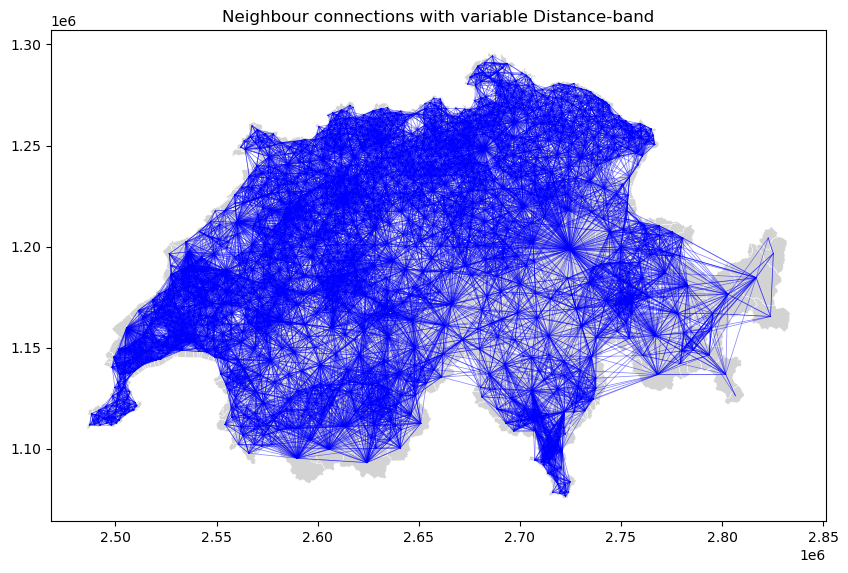

In [95]:
coords = gdf_sa_pv_clean.geometry.centroid

fig, ax = plt.subplots(figsize=(10, 10))

# Plot municipalities
gdf_sa_pv_clean.plot(ax=ax, facecolor="lightgray", edgecolor="white", linewidth=0.3)

# Plot lines connecting neighbors
for i, neighbors in W_dist_pv.neighbors.items():
    xi, yi = coords.iloc[i].x, coords.iloc[i].y
    for j in neighbors:
        xj, yj = coords.iloc[j].x, coords.iloc[j].y
        ax.plot([xi, xj], [yi, yj], linewidth=0.5, color="blue", alpha=0.5)

plt.title("Neighbour connections with variable Distance-band")
plt.show()

Check maximum correlation among variables

In [96]:
X_std_df = pd.DataFrame(
    X_pv_std,
    columns=cols_X_pv_std
)

corr = X_std_df.corr()

threshold = 0.5
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        cij = corr.iloc[i, j]
        if abs(cij) > threshold:
            high_corr_pairs.append(
                (corr.index[i], corr.columns[j], cij)
            )

print("Pairs of variables with high correlation:")
for a, b, cval in high_corr_pairs:
    print(f" - {a} vs {b}: corr = {cval:.3f}")


Pairs of variables with high correlation:
 - std_Secondary House Rate [%] vs std_People Below 19 [%]: corr = -0.516
 - std_People Over 80 [%] vs std_Population Density: corr = 0.514
 - std_People Below 19 [%] vs std_Households Over 5 People [%]: corr = 0.632
 - std_Foreigners Share [%] vs std_Population Density: corr = 0.507


### 4.3.2 HP

In [97]:
# Independent variables for HP (commented out lines produce a p-value>0.05)

# Columns to standardize
cols_std_hp = [
    "EV share [%]",
#    "Tertiary Education Rate [%]",
    "Home Ownership Rate [%]",
    "Secondary House Rate [%]",
    "People Over 65 [%]",
    "People Below 19 [%]",
    "Foreigners Share [%]",
    "log_Mean_Income",
    "Population Density",
#    "Electricity Price (cts./kWh)",
    "CO2Act Yes Share [%]",
    "Building Age",
    "Households Over 5 People [%]",
    "Green party [%]"
    
]

# Columns NOT to standardize
cols_nostd_hp = [
#    "SFH_share",
#    "DFH_share",
#    "AreaType_1",
#    "AreaType_2",
    "DH_share",
#    "City energy label binary"
]

cols_needed = ["HP_share", "Population"] + cols_std_hp + cols_nostd_hp

gdf_sa_hp_clean = gdf_spatial_analysis.dropna(subset=cols_needed).reset_index(drop=True)

X_cont = gdf_sa_hp_clean[cols_std_hp].to_numpy()

# Standardization (mean=0, std=1)
scaler_hp = StandardScaler()
X_cont_std = scaler_hp.fit_transform(X_cont)

# Add non-standardized variables (SFH_share, DFH_share)
X_nostd = gdf_sa_hp_clean[cols_nostd_hp].to_numpy()

# Final standardized X matrix for the model
X_hp_std = np.column_stack([X_cont_std, X_nostd])

# Names to use
cols_X_hp_std = [f"std_{c}" for c in cols_std_hp] + cols_nostd_hp

# y NOT scaled
y_hp = gdf_sa_hp_clean["HP_share"].to_numpy().reshape(-1, 1)

W_dist_hp, W_queen_hp, W_queen_pop_hp = build_W_matrix(gdf_sa_hp_clean)

model_hp_std = GM_Combo_Het(
    y_hp,
    X_hp_std,
    w=W_dist_hp,
    name_y="HP_share",
    name_x=cols_X_hp_std,
    name_w="W_variable_distance_pop"
)
print(model_hp_std.summary)


C:\Users\andre\AppData\Local\Temp\ipykernel_42060\4201715919.py:45: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_queen = Queen.from_dataframe(gdf_clean)
c:\Users\andre\anaconda3\envs\semproj\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 1131.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 1131, ' is an island (no neighbors)')
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIALLY WEIGHTED 2SLS- GM-COMBO MODEL (HET)
----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :W_variable_distance_pop
Dependent Variable  :    HP_share                Number of Observations:        2083
Mean dependent var  :      0.2670                Number of Variables   :          15
S.D. dependent var  :      0.1244                Degrees of Freedom    :        2068
Pseudo R-squared    :      0.5797
Spatial Pseudo R-squared:  0.4790
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.21135

Check maximum correlation among variables

In [98]:
X_std_df = pd.DataFrame(
    X_hp_std,
    columns=cols_X_hp_std
)

corr = X_std_df.corr()

threshold = 0.5
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        cij = corr.iloc[i, j]
        if abs(cij) > threshold:
            high_corr_pairs.append(
                (corr.index[i], corr.columns[j], cij)
            )

print("Pairs of variables with high correlation (>|0.5|):")
for a, b, cval in high_corr_pairs:
    print(f" - {a} vs {b}: corr = {cval:.3f}")


Pairs of variables with high correlation (>|0.5|):
 - std_EV share [%] vs std_log_Mean_Income: corr = 0.568
 - std_Secondary House Rate [%] vs std_People Over 65 [%]: corr = 0.549
 - std_Secondary House Rate [%] vs std_People Below 19 [%]: corr = -0.516
 - std_People Over 65 [%] vs std_People Below 19 [%]: corr = -0.698
 - std_People Below 19 [%] vs std_Households Over 5 People [%]: corr = 0.632
 - std_Foreigners Share [%] vs std_Population Density: corr = 0.507
 - std_CO2Act Yes Share [%] vs std_Green party [%]: corr = 0.532


### 4.3.3 Unobservables

In [99]:
# Residuals PV + municipalities
res_pv = pd.DataFrame({
    "Municipality": gdf_sa_pv_clean["Municipality"].to_numpy(),
    "e_pv": model_pv_std.u.flatten()
})

# Residuals HP + municipalities
res_hp = pd.DataFrame({
    "Municipality": gdf_sa_hp_clean["Municipality"].to_numpy(),
    "e_hp": model_hp_std.u.flatten()
})

# Keep only municipalities present in both models
res_both = pd.merge(res_pv, res_hp, on="Municipality", how="inner")

print(f"Number of municipalities in common: {len(res_both)}")

# Pearson correlation between residuals
corr_res = np.corrcoef(res_both["e_pv"], res_both["e_hp"])[0, 1]
print(f"Correlation between the residuals of PV and HP models: {corr_res:.4f}")


Number of municipalities in common: 2083
Correlation between the residuals of PV and HP models: 0.2081


## 4.4 Seemingly Unrelated Regressions (SUR)

In [101]:
cols_std_common = cols_std_pv  # or cols_std_hp, it's the same
cols_nostd_union = list(dict.fromkeys(cols_nostd_pv + cols_nostd_hp))
cols_needed_raw = (
    ["PV_share", "HP_share", "Population"]
    + cols_std_common
    + cols_nostd_union
)

# Remove NaNs
gdf_sa_both = gdf_spatial_analysis.dropna(subset=cols_needed_raw).reset_index(drop=True)

# Standardize all the common continuous variables inside gdf_sa_both
X_cont = gdf_sa_both[cols_std_common].to_numpy()

scaler_both = StandardScaler()
X_cont_std = scaler_both.fit_transform(X_cont)

# Create the names of the standardized columns
cols_std_common_std = [f"std_{c}" for c in cols_std_common]

# Add the std_... columns to the GeoDataFrame
gdf_sa_both[cols_std_common_std] = X_cont_std

# Define the lists of regressors for the two equations
cols_X_pv_std = cols_std_common_std + cols_nostd_pv
cols_X_hp_std = cols_std_common_std + cols_nostd_hp

# Number of observations
n = gdf_sa_both.shape[0]

# Build dependent variables
y_pv = gdf_sa_both["PV_share"].to_numpy().reshape(-1, 1)
y_hp = gdf_sa_both["HP_share"].to_numpy().reshape(-1, 1)

bigy = {
    0: y_pv,  # equation 0: PV
    1: y_hp,  # equation 1: HP
}

# Build X for the two equations (with constant)
X_pv = gdf_sa_both[cols_X_pv_std].to_numpy()
X_hp = gdf_sa_both[cols_X_hp_std].to_numpy()

const = np.ones((n, 1))

X_pv_with_const = np.hstack([const, X_pv])
X_hp_with_const = np.hstack([const, X_hp])

bigX = {
    0: X_pv_with_const,
    1: X_hp_with_const,
}

# Names of the variables (for the output)
name_bigy = {0: "PV_share", 1: "HP_share"}
name_bigX = {
    0: ["const"] + cols_X_pv_std,
    1: ["const"] + cols_X_hp_std,
}

W_dist, W_queen, W_queen_pop = build_W_matrix(gdf_sa_both)


# Estimate the joint SUR model
sur_model = SUR(
    bigy,
    bigX,
    w=W_dist,             # optional: same W used for PV/HP (only for spatial diagnostics)
    name_bigy=name_bigy,
    name_bigX=name_bigX,
    name_w="W_10km_pop",
    name_ds="PV_HP_joint",
    spat_diag=True        # also provides LM test for spatial lag/error
)

print(sur_model.summary)

# Joint error correlation matrix (true bivariate "ρ")
print("Error correlation matrix between equations:")
print(sur_model.corr)


C:\Users\andre\AppData\Local\Temp\ipykernel_42060\4201715919.py:45: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_queen = Queen.from_dataframe(gdf_clean)


('WARNING: ', 1131, ' is an island (no neighbors)')
REGRESSION
----------
SUMMARY OF OUTPUT: SEEMINGLY UNRELATED REGRESSIONS (SUR)
--------------------------------------------------------
Data set            : PV_HP_joint
Weights matrix      :  W_10km_pop
Number of Equations :           2                Number of Observations:        2083
Log likelihood (SUR):    5281.342                Number of Iterations  :           1
----------

SUMMARY OF EQUATION 1
---------------------
Dependent Variable  :    PV_share                Number of Variables   :          16
Mean dependent var  :      0.1581                Degrees of Freedom    :        2067
S.D. dependent var  :      0.0724

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
               const       0.0498168       0.0140036      

c:\Users\andre\anaconda3\envs\semproj\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 1131.
  W.__init__(self, neighbors, ids=ids, **kw)
